## Downloading the dataset

Install PILArNet `V3_extra` from huggingface if you haven't already by running the following command in your terminal:

if using `uv`:

```bash
uv run python scripts/pilarnet/download.py --revision v3_extra --output-dir /path/to/dir --no-env-setup
```

if using `conda`:

```bash
python scripts/pilarnet/download.py --revision v3_extra --output-dir /path/to/dir --no-env-setup
```

If you have access to S3DF, PILArNet is installed here: `/sdf/home/y/youngsam/data/dune/datasets/pilarnet/V3_EXTRA`.

More information on the dataset can be found in the HF readme here: https://huggingface.co/datasets/DeepLearnPhysics/PILArNet-M/blob/v3_extra/README.md

## Loading in the dataset

In [ ]:
from pimm.datasets import build_dataset, collate_fn
from pimm.datasets.pilarnet import default_transform, V3_EXTRA_KEYS

PILARNET_DATA_DIR = "/sdf/home/y/youngsam/data/dune/datasets/pilarnet/V3_EXTRA" # location on S3DF

# regular PyTorch dataset
dataset = build_dataset(
    dict(
        type="PILArNetH5Dataset",
        data_root=PILARNET_DATA_DIR,
        split="test", # "train", "val", "test"
        transform=default_transform(extra_keys=V3_EXTRA_KEYS),
        min_points=1024, # skip events with # of points less than 1024
    )
)
type(dataset)

[2026-08-20 09:31:39,444 INFO h5.py line 218] Building index for PILArNetH5Dataset


[2026-08-20 09:31:39,449 INFO h5.py line 255] Found 48327 point clouds with at least 1024 points
[2026-08-20 09:31:39,450 INFO h5.py line 191] Total number of samples in PILArNet 48327 set: 1 x test.


pimm.datasets.pilarnet.h5.PILArNetH5Dataset

In [ ]:
def describe(d):
    for key, value in d.items():
        shape = tuple(value.shape) if hasattr(value, "shape") else None
        print(f"{key:20} |  shape: {shape}")

data = dataset[0] # first event
describe(data)

importantly, the dataloader outputs particle-level quantities at the pixel level; i.e. each pixel corresponds to a SINGLE particle. to find the particle isntance they correspond to, we use `instance_particle`:

In [56]:
import torch

print("Instance particle for one event:\t" , data['instance_particle'].squeeze())
unique, counts = torch.unique(data["instance_particle"], return_counts=True)
print("Unique particle IDs (incl. -1):\t\t", unique)
print("Number of points / unique particle\t", counts)

Instance particle for one event:	 tensor([ 8,  8,  8,  ...,  7, -1, -1])
Unique particle IDs (incl. -1):		 tensor([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9])
Number of points / unique particle	 tensor([ 34, 751,  17,  20,  12,  17,  71,  79,  32,  85,  57])


before we go further let's look at the characteristics of the first particle instance, which seems to have a unique ID of 8:

In [78]:
PARTICLE_ID = 8
MASK = data['instance_particle'].eq(PARTICLE_ID).squeeze() # (N, )

particle_data = {k: v[MASK] if k != "offset" else v for k, v in data.items()}
describe(particle_data)

coord                |  shape: (85, 3)
grid_coord           |  shape: (85, 3)
energy               |  shape: (85, 1)
segment_motif        |  shape: (85, 1)
segment_pid          |  shape: (85, 1)
segment_interaction  |  shape: (85, 1)
instance_particle    |  shape: (85, 1)
instance_interaction |  shape: (85, 1)
mass                 |  shape: (85, 1)
px                   |  shape: (85, 1)
py                   |  shape: (85, 1)
pz                   |  shape: (85, 1)
momentum_vector      |  shape: (85, 3)
momentum_vec         |  shape: (85, 3)
true_energy          |  shape: (85, 1)
parent_pdg           |  shape: (85, 1)
parent_track_id      |  shape: (85, 1)
interaction_vertex   |  shape: (85, 3)
is_primary_4cls      |  shape: (85, 1)
offset               |  shape: (1,)
feat                 |  shape: (85, 4)


because these are all pixels that correspond to the same particle, we only expect `coords`, `grid_coord` (which contains quantized coordinates for use by a sparse CNN), `energy`, and `feat` (which is `cat[coord, energy]`, used as model input features) to contain >1 unique value. thus you can just take the first value from each array.

In [121]:
for k, v in particle_data.items():
    all_same = torch.unique(v.squeeze()).numel() == v.shape[-1]
    value = None
    if all_same and v.shape[0]>1:
        value = next(iter(v.squeeze()))
    print(f"{k:20} | all same?  {all_same}  {f'= {value}' if value is not None else ''}")

coord                | all same?  False  
grid_coord           | all same?  False  
energy               | all same?  False  
segment_motif        | all same?  True  = 1
segment_pid          | all same?  True  = 2
segment_interaction  | all same?  True  = 1
instance_particle    | all same?  True  = 8
instance_interaction | all same?  True  = 3
mass                 | all same?  True  = 0.10565799474716187
px                   | all same?  True  = 0.5773734450340271
py                   | all same?  True  = 0.23098620772361755
pz                   | all same?  True  = -0.735403299331665
momentum_vector      | all same?  True  = tensor([ 0.5774,  0.2310, -0.7354])
momentum_vec         | all same?  True  = tensor([ 0.5995,  0.2398, -0.7636])
true_energy          | all same?  True  = 0.9688634276390076
parent_pdg           | all same?  True  = 0
parent_track_id      | all same?  True  = 1385
interaction_vertex   | all same?  True  = tensor([5.5005e+02, 9.1000e-03, 4.8214e+01])
is_primary_4c

In LArTPCs, because $\pi^0$s are neutral, we don't see them directly in the detector. Instead, we usually see their decay photons. The dominant decay is $\pi^0 \rightarrow \gamma\gamma$, and the [PDG value](https://pdglive.lbl.gov/Particle.action?node=S009) of the $\pi^0$ mass is about 135 MeV ($0.135$ GeV).

`parent_pdg` and `parent_track_id` are Monte Carlo **truth** fields in PILArNet `V3_EXTRA`. They provide the immediate simulated parent species and the particular parent track. Therefore, the correct truth-level way to identify the two photons from one $\pi^0$ is to:

* select distinct particle instances whose particle type is photon and whose `parent_pdg == 111`;
* group them by `(event, parent_track_id)`&mdash;track IDs are only meaningful within an event; and
* retain groups containing exactly two photons. A one-photon group means that the other photon is absent from the selected/visible sample; it should not be paired with a photon from another parent.

This establishes the true decay association; it is not a reconstruction algorithm that can be applied to detector data. For reconstruction, where parent truth is unavailable, one instead forms candidate pairs of reconstructed photons (normally within the same interaction/vertex) and calculates

$$m_{\gamma\gamma}^2 = (p_{\gamma_1} + p_{\gamma_2})^2 = 2 E_1 E_2 (1 - \cos\theta_{12}),$$

then resolves combinatorics and selects candidates compatible with the $\pi^0$ mass. In this tutorial, using `parent_track_id` after truth matching is intentionally an oracle-level illustration.

## Event streaming

of course, we are using data loaders here, so we want to load in a large number of events in a single batch. we do this using the normal PyTorch dataloader, but we need to use a custom collate function:

In [125]:
# loading batches
from torch.utils.data import DataLoader
from pimm.datasets import collate_fn

dl = DataLoader(dataset, batch_size=32, collate_fn=collate_fn)

batch = next(iter(dl))

describe(batch)

coord                |  shape: (98154, 3)
grid_coord           |  shape: (98154, 3)
energy               |  shape: (98154, 1)
segment_motif        |  shape: (98154, 1)
segment_pid          |  shape: (98154, 1)
segment_interaction  |  shape: (98154, 1)
instance_particle    |  shape: (98154, 1)
instance_interaction |  shape: (98154, 1)
mass                 |  shape: (98154, 1)
px                   |  shape: (98154, 1)
py                   |  shape: (98154, 1)
pz                   |  shape: (98154, 1)
momentum_vector      |  shape: (98154, 3)
momentum_vec         |  shape: (98154, 3)
true_energy          |  shape: (98154, 1)
parent_pdg           |  shape: (98154, 1)
parent_track_id      |  shape: (98154, 1)
interaction_vertex   |  shape: (98154, 3)
is_primary_4cls      |  shape: (98154, 1)
offset               |  shape: (32,)
feat                 |  shape: (98154, 4)


here, you can see we have very large 2D arrays for these 32 events. ragged lists of events are difficult to deal with, and usually one will combine many into a batch in two ways: (1) padding all images to some maximum point count to give a 3D batched array of shape `(batch, n_point_max, ?)`, or (2) save in CSR format, with compressed rows flattened into a single array, and a separate *indexing* array that tells you which parts of the flattened array correspond to separate images. There are of course tradeoffs for both of these, but we find that the CSR format is more desirable.

Our indexing array we have available is `offset` here. It is equivalent to the cumulative sum of an array that gives the length of each image. You can for example separate out events like such:

In [127]:
events = []
offsets = batch["offset"]
print(offsets)
start = 0
for end in offsets.tolist():
    events.append(
        {k: v[start:end] for k, v in batch.items() if k != "offset"}
    )
    start = end

tensor([ 1175,  2364,  5352,  9747, 11188, 17260, 18933, 22491, 28206, 33690,
        34948, 37913, 40773, 42547, 44168, 48219, 52924, 54442, 56679, 60358,
        63604, 67777, 70841, 72466, 73950, 76555, 83426, 85404, 88809, 92845,
        95051, 98154])


In [135]:
print(len(events), "events. event 0:"); describe(events[0])

32 events. event 0:
coord                |  shape: (1175, 3)
grid_coord           |  shape: (1175, 3)
energy               |  shape: (1175, 1)
segment_motif        |  shape: (1175, 1)
segment_pid          |  shape: (1175, 1)
segment_interaction  |  shape: (1175, 1)
instance_particle    |  shape: (1175, 1)
instance_interaction |  shape: (1175, 1)
mass                 |  shape: (1175, 1)
px                   |  shape: (1175, 1)
py                   |  shape: (1175, 1)
pz                   |  shape: (1175, 1)
momentum_vector      |  shape: (1175, 3)
momentum_vec         |  shape: (1175, 3)
true_energy          |  shape: (1175, 1)
parent_pdg           |  shape: (1175, 1)
parent_track_id      |  shape: (1175, 1)
interaction_vertex   |  shape: (1175, 3)
is_primary_4cls      |  shape: (1175, 1)
feat                 |  shape: (1175, 4)


as you can see the first event contains 1175 points, which is the size of our original first array when we indexed `dataset[0]` above

## Panda Base inference

Panda Base is the base encoder we pre-trained with the DINO-like SSL objective as described in [arXiv:2512.01324](https://arxiv.org/abs/2512.01324). Using it for inference is relatively straightforward using `pimm`. Our API is similar to `timm`, and we generally load in pretrained models using HuggingFace:

In [ ]:
import pimm

model = pimm.from_pretrained("deeplearnphysics/panda-base", device="cuda") # weights are saved to $HF_HOME/hub; by default this is ~/.cache/huggingface/hub/

Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 330.06it/s]


In [149]:
from pimm.distributed import move_batch_to_device

batch = move_batch_to_device(next(iter(dl)), "cuda")
with torch.inference_mode():
    point = model(batch)

W0820 10:27:29.100000 3974802 .venv/lib/python3.10/site-packages/torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


In [154]:
describe(point)

feat                 |  shape: (12622, 512)
coord                |  shape: (12622, 512)
grid_coord           |  shape: (12622, 512)
batch                |  shape: (12622, 512)
segment_motif        |  shape: (12622, 512)
pooling_inverse      |  shape: (12622, 512)
pooling_parent       |  shape: (12622, 512)
offset               |  shape: (12622, 512)
order                |  shape: (12622, 512)
serialized_depth     |  shape: (12622, 512)
serialized_code      |  shape: (12622, 512)
serialized_order     |  shape: (12622, 512)
serialized_inverse   |  shape: (12622, 512)
sparse_shape         |  shape: (12622, 512)
sparse_conv_feat     |  shape: (12622, 512)
pad                  |  shape: (12622, 512)
unpad                |  shape: (12622, 512)
cu_seqlens_key       |  shape: (12622, 512)


this gives us the output of the panda encoder; note that it's the first half of a UNet, so we are given the output at the coarsest level, hence why we only have 12622 points instead of the 98154 from the batch input. output, which is a thin wrapper around a dictionary called `Point`, has a method called `upcast()`, which traverses each level back up to the original input resolution. Crucially, along the way, it concatenated point features from each level, much like a conventional feature pyramid, to output per-point features.

In [157]:
point = point.upcast()
describe(point)

coord                |  shape: (98154, 1232)
grid_coord           |  shape: (98154, 1232)
energy               |  shape: (98154, 1232)
segment_motif        |  shape: (98154, 1232)
segment_pid          |  shape: (98154, 1232)
segment_interaction  |  shape: (98154, 1232)
instance_particle    |  shape: (98154, 1232)
instance_interaction |  shape: (98154, 1232)
mass                 |  shape: (98154, 1232)
px                   |  shape: (98154, 1232)
py                   |  shape: (98154, 1232)
pz                   |  shape: (98154, 1232)
momentum_vector      |  shape: (98154, 1232)
momentum_vec         |  shape: (98154, 1232)
true_energy          |  shape: (98154, 1232)
parent_pdg           |  shape: (98154, 1232)
parent_track_id      |  shape: (98154, 1232)
interaction_vertex   |  shape: (98154, 1232)
is_primary_4cls      |  shape: (98154, 1232)
offset               |  shape: (98154, 1232)
feat                 |  shape: (98154, 1232)
batch                |  shape: (98154, 1232)
order     

let's plot the output from one event:

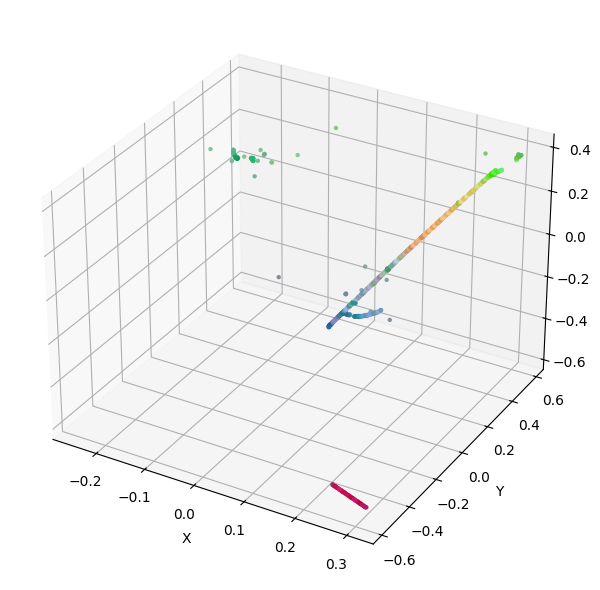

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401, required for 3D plotting

coord = point.coord[:point.offset[0]].cpu().numpy() # (1175, 3)
feats = point.feat[:point.offset[0]].detach() # (1175, 1232)

# convert feats to RGB using PCA:
feats_np = feats.cpu()
feats_centered = feats_np - feats_np.mean(dim=0, keepdim=True)
U, S, V = torch.pca_lowrank(feats_centered, q=3)
rgb_feats = feats_centered @ V[:, :3]
rgb_min = rgb_feats.min(dim=0, keepdim=True)[0]
rgb_max = rgb_feats.max(dim=0, keepdim=True)[0]
rgb = (rgb_feats - rgb_min) / (rgb_max - rgb_min + 1e-8)
rgb = rgb.clamp(0, 1).numpy()


fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    coord[:, 0],
    coord[:, 1],
    coord[:, 2],
    c=rgb,
    s=10,  # marker size, adjusted for matplotlib
    alpha=0.8,
    linewidths=0
)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.tight_layout()
plt.show()

nice!

# Inference with Panda Particle and Panda Interaction

We have two separate fine-tuned models, panda particle and panda interaction, which perform particle and interaction-level instance segmentation.

In [175]:
particle = pimm.from_pretrained("deeplearnphysics/panda-particle", device='cuda')
interaction = pimm.from_pretrained("deeplearnphysics/panda-interaction", device='cuda')

Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 511.17it/s]


In [178]:
import copy

batch = next(iter(dl))
outputs = {}
with torch.inference_mode():
    for name, mod in (("particle", particle), ("interaction", interaction)):
        _batch = move_batch_to_device(copy.deepcopy(batch), "cuda")
        raw_outputs = mod(_batch)
        postprocessed = mod.postprocess(raw_outputs)
        outputs[name] = {"raw_output": raw_outputs, "postprocessed": postprocessed}

For now, we likely just want to work with postprocessed outputs. `model.postprocess` takes decoded queries, masks, class predictions, etc. and uses NMS to deduplicate predictions and return a nice set of predictions for downstream consumption:

In [ ]:
int_pp = outputs['interaction']['postprocessed']
for k, v in int_pp.items():
    print(f"{k}: {v}")

instance_labels: tensor([  4,   4,   4,  ..., 150, 150, 150], device='cuda:0')
class_labels: tensor([1, 1, 1,  ..., 1, 1, 1], device='cuda:0')
confidences: tensor([0.7907, 0.7907, 0.7907,  ..., 0.9285, 0.9285, 0.9285], device='cuda:0')
query_labels: tensor([6, 6, 6,  ..., 3, 3, 3], device='cuda:0')


again, we can view predictions for the first event:

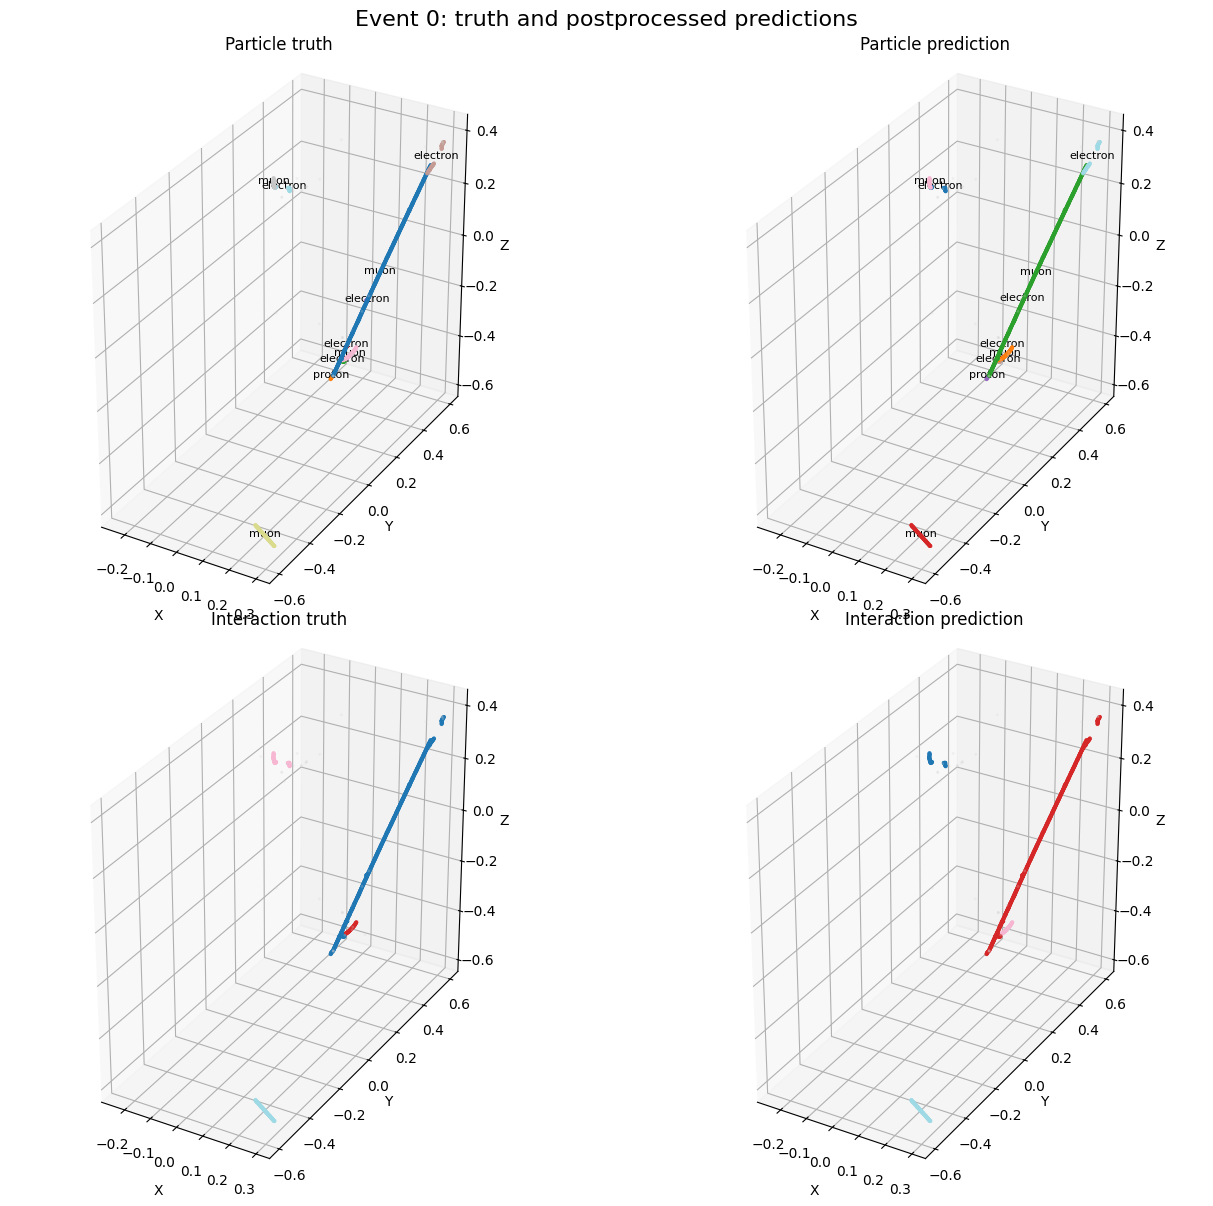

In [218]:
PID_NAMES = ("photon", "electron", "muon", "pion", "proton", "LED")
EVENT_INDEX = 0


def event_bounds(offsets, event_index):
    start = 0 if event_index == 0 else int(offsets[event_index - 1].item())
    end = int(offsets[event_index].item())
    return start, end


def plot_instances(ax, coord, instances, title, categories=None):
    coord = coord.detach().cpu()
    instances = instances.detach().cpu().reshape(-1)
    categories = None if categories is None else categories.detach().cpu().reshape(-1)

    background = instances < 0
    if background.any():
        xyz = coord[background].numpy()
        ax.scatter(*xyz.T, color="lightgray", s=4, alpha=0.25, linewidths=0)

    instance_ids = torch.unique(instances[instances >= 0])
    cmap = plt.get_cmap("tab20", max(len(instance_ids), 1))
    for color_index, instance_id in enumerate(instance_ids.tolist()):
        mask = instances == instance_id
        xyz = coord[mask].numpy()
        ax.scatter(*xyz.T, color=[cmap(color_index)], s=8, alpha=0.8, linewidths=0)

        if categories is not None:
            valid_categories = categories[mask]
            valid_categories = valid_categories[valid_categories >= 0]
            if len(valid_categories):
                category = int(torch.mode(valid_categories).values.item())
                category_name = PID_NAMES[category] if category < len(PID_NAMES) else str(category)
                centroid = xyz.mean(axis=0)
                ax.text(*centroid, category_name, fontsize=8, ha="center")

    xyz = coord.numpy()
    span = (xyz.max(axis=0) - xyz.min(axis=0)).clip(min=1e-3)
    ax.set_box_aspect(span)
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")


start, end = event_bounds(batch["offset"], EVENT_INDEX)
coord = batch["coord"][start:end]
particle_pp = outputs["particle"]["postprocessed"]
interaction_pp = outputs["interaction"]["postprocessed"]

fig = plt.figure(figsize=(14, 12))
axes = [fig.add_subplot(2, 2, i + 1, projection="3d") for i in range(4)]
plot_instances(
    axes[0], coord, batch["instance_particle"][start:end],
    "Particle truth", batch["segment_pid"][start:end],
)
plot_instances(
    axes[1], coord, particle_pp["instance_labels"][start:end],
    "Particle prediction", particle_pp["class_labels"][start:end],
)
plot_instances(
    axes[2], coord, batch["instance_interaction"][start:end],
    "Interaction truth",
)
plot_instances(
    axes[3], coord, interaction_pp["instance_labels"][start:end],
    "Interaction prediction",
)
fig.suptitle(f"Event {EVENT_INDEX}: truth and postprocessed predictions", fontsize=16)
plt.tight_layout()
plt.show()

## Accessing other particle-level attributes for predicted particles

Panda particle and interaction are two separate models that do not predict other particle- or interaction-level quantities that would be helpful for an analysis, like vertex position, momentum/energy, direction, etc. Models currently in development target predictions for these quantities (at least for all of these except momentum/energy, which is usually done with non-ML-based postprocessing on reconstruction outputs).

For now, we can "fake" having these reconstructed quantities by matching model predictions to ground-truth instances and copying the corresponding truth values. The helper below deep-copies the two postprocessed dictionaries, removes unmatched predicted instances in the copies, attaches attributes directly at the top level, and records matching information under `matches`. Points from unmatched predictions are marked as background. Matching is performed separately within each event using a one-to-one Hungarian assignment with mask IoU $>0.5$.

In [225]:
from scipy.optimize import linear_sum_assignment


def attach_ground_truth(particle_output, interaction_output, batch, iou_threshold=0.5):
    """Return postprocessed outputs containing only truth-matched instances."""
    particle_output, interaction_output = copy.deepcopy(
        (particle_output, interaction_output)
    )

    # Each task has its own truth instance labels and attributes to transfer.
    outputs = {"particle": particle_output, "interaction": interaction_output}
    fields = {
        "particle": {name: batch[name] for name in V3_EXTRA_KEYS if name in batch},
        "interaction": {"interaction_vertex": batch["interaction_vertex"]},
    }
    truth_keys = {
        "particle": "instance_particle",
        "interaction": "instance_interaction",
    }

    for task, output in outputs.items():
        pred = output["instance_labels"]
        device = pred.device
        pred_cpu = pred.detach().cpu().reshape(-1)
        truth_cpu = batch[truth_keys[task]].detach().cpu().reshape(-1)
        # allocate point-aligned outputs. NaN/-1 means no accepted match.
        attributes = {}
        for name, values in fields[task].items():
            fill = float("nan") if values.is_floating_point() else -1
            attributes[name] = torch.full(
                (pred.numel(), *values.shape[1:]), fill,
                dtype=values.dtype, device=device,
            )

        truth_labels = torch.full_like(pred, -1)
        match_iou = torch.full(pred.shape, float("nan"), device=device)
        matches = []
        # Truth instance IDs restart in every event, so match event-by-event.
        start = 0
        for event, end in enumerate(batch["offset"].detach().cpu().tolist()):
            event_pred, event_truth = pred_cpu[start:end], truth_cpu[start:end]
            pred_ids = torch.unique(event_pred[event_pred >= 0])
            truth_ids = torch.unique(event_truth[event_truth >= 0])
            if len(pred_ids) and len(truth_ids):
                # One boolean mask per predicted and true instance.
                pred_masks = event_pred.unsqueeze(0) == pred_ids.unsqueeze(1)
                truth_masks = event_truth.unsqueeze(0) == truth_ids.unsqueeze(1)
                intersections = pred_masks.float() @ truth_masks.float().T
                unions = (pred_masks.sum(1, keepdim=True)
                          + truth_masks.sum(1).unsqueeze(0) - intersections)
                ious = intersections / unions.clamp_min(1)

                # Hungarian assignment is one-to-one. scipy minimizes, so
                # negate IoU to find the assignment with maximum total IoU.
                rows, cols = linear_sum_assignment(-ious.numpy())

                for row, col in zip(rows, cols):
                    iou = float(ious[row, col])
                    if iou <= iou_threshold:
                        continue
                    pred_id, truth_id = int(pred_ids[row]), int(truth_ids[col])
                    pred_mask = event_pred == pred_id
                    indices = (torch.nonzero(pred_mask).flatten() + start).to(device)
                    truth_index = start + torch.nonzero(
                        event_truth == truth_id
                    )[0].item()

                    # Copy the matched truth values onto every point in the
                    # predicted instance, matching postprocess' layout.
                    truth_labels[indices], match_iou[indices] = truth_id, iou
                    for name, values in fields[task].items():
                        attributes[name][indices] = values[truth_index].to(device)
                    matches.append({
                        "event": event, "predicted_instance": pred_id,
                        "truth_instance": truth_id, "iou": iou,
                    })
            start = end

        # Suppress unmatched predicted instances while preserving the full
        # point alignment with batch coordinates and offsets.
        matched = truth_labels >= 0
        for key in ("instance_labels", "class_labels", "query_labels"):
            if key in output:
                output[key][~matched] = -1
        if "confidences" in output:
            output["confidences"][~matched] = 0

        # Attributes are top-level for direct access, e.g.
        # matched_particles["momentum_vector"].
        output.update(attributes)
        output.update(
            truth_instance_labels=truth_labels, match_iou=match_iou, matches=matches,
        )

    return outputs


matched_outputs = attach_ground_truth(particle_pp, interaction_pp, batch)
matched_particles = matched_outputs["particle"]
matched_interactions = matched_outputs["interaction"]
print(
    f"Matched {len(matched_particles['matches'])} particles and "
    f"{len(matched_interactions['matches'])} interactions."
)
matched_particles["matches"][:5]

Matched 371 particles and 121 interactions.


[{'event': 0, 'predicted_instance': 1, 'truth_instance': 9, 'iou': 1.0},
 {'event': 0, 'predicted_instance': 2, 'truth_instance': 6, 'iou': 1.0},
 {'event': 0,
  'predicted_instance': 3,
  'truth_instance': 0,
  'iou': 0.9920634627342224},
 {'event': 0, 'predicted_instance': 4, 'truth_instance': 8, 'iou': 1.0},
 {'event': 0, 'predicted_instance': 5, 'truth_instance': 1, 'iou': 1.0}]

In [227]:
describe(matched_outputs["particle"])

instance_labels      |  shape: (98154,)
class_labels         |  shape: (98154,)
confidences          |  shape: (98154,)
query_labels         |  shape: (98154,)
matched_truth        |  shape: (98154,)
mass                 |  shape: (98154,)
px                   |  shape: (98154,)
py                   |  shape: (98154,)
pz                   |  shape: (98154,)
momentum_vector      |  shape: (98154,)
momentum_vec         |  shape: (98154,)
true_energy          |  shape: (98154,)
parent_pdg           |  shape: (98154,)
parent_track_id      |  shape: (98154,)
interaction_vertex   |  shape: (98154,)
is_primary_4cls      |  shape: (98154,)
truth_instance_labels |  shape: (98154,)
match_iou            |  shape: (98154,)
matches              |  shape: (98154,)
